# Day 135 — Imbalanced Datasets & SMOTE
## Month 7 | Advanced ML | RetailPulse India (seed=121, 500 rows)

> **Topic:** Class imbalance is the silent killer of churn models.
> Your model says 82.6% accuracy — but it never predicted a single churner.
> Today you learn to detect, diagnose, and fix that.

**Sections**
1. Raw Data
2. Practice Tasks (A–E★)
3. Concept Notes
4. Answer Key
5. Scoring Rubric

**Total: 80 pts + 10★ bonus**

---
### ⚙️ Install (run once)
```python
!pip install imbalanced-learn -q
```

---
## Section 1 — Raw Data *(never modify this cell)*

In [1]:
# ── SECTION 1: RAW DATA — DO NOT MODIFY ──────────────────────────────────────
import numpy as np
import pandas as pd

np.random.seed(121)
n = 500
categories = ['Electronics','Clothing','Groceries','Home Decor','Sports']
regions    = ['North','South','East','West']

df_raw = pd.DataFrame({
    'customer_id':        range(1, n+1),
    'age':                np.random.randint(18, 65, n),
    'region':             np.random.choice(regions, n),
    'product_category':   np.random.choice(categories, n),
    'purchase_frequency': np.random.randint(1, 20, n),
    'avg_order_value':    np.round(np.random.uniform(200, 5000, n), 2),
    'total_revenue':      np.round(np.random.uniform(1000, 50000, n), 2),
    'discount_used':      np.random.choice([0, 1], n, p=[0.6, 0.4]),
    'returns_count':      np.random.randint(0, 5, n),
    'churned':            np.random.choice([0, 1], n, p=[0.82, 0.18])
})

print("Shape:", df_raw.shape)
print("\nChurn distribution:")
print(df_raw['churned'].value_counts())
print("\nChurn rate:", round(df_raw['churned'].mean()*100, 1), "%")
print("\nFirst 5 rows:")
print(df_raw.head())

Shape: (500, 10)

Churn distribution:
churned
0    413
1     87
Name: count, dtype: int64

Churn rate: 17.4 %

First 5 rows:
   customer_id  age region product_category  purchase_frequency  \
0            1   20   East       Home Decor                  19   
1            2   39   East         Clothing                  14   
2            3   26  South      Electronics                   3   
3            4   49  South         Clothing                  14   
4            5   19  North         Clothing                   8   

   avg_order_value  total_revenue  discount_used  returns_count  churned  
0          2274.00        8193.09              1              2        1  
1           845.16        6900.48              0              0        1  
2          2318.98       35246.82              0              3        0  
3           225.30       41213.88              0              4        0  
4          1571.39        4671.11              0              0        0  


---
## Section 2 — Practice Tasks

### Task A — Diagnose the Imbalance (20 pts)

**Business context:** Before building any churn model, you must prove to your client
that a naive model is dangerous — high accuracy but zero recall on churners.

**A1 (5 pts):** Print class counts and imbalance ratio.
- Compute: `majority_count`, `minority_count`, `imbalance_ratio` (majority/minority, 1 decimal)
- Print: `Imbalance ratio: X.X:1`

**A2 (5 pts):** Train a `DummyClassifier(strategy='most_frequent')` on the full dataset.
- Use features: `age, purchase_frequency, avg_order_value, total_revenue, discount_used, returns_count`
- Print: accuracy, precision (churned=1), recall (churned=1), F1 (churned=1)
- Use `classification_report` with `target_names=['retained','churned']`

**A3 (10 pts):** Train a `LogisticRegression(max_iter=1000, random_state=42)` on the
**raw imbalanced** data (80/20 train-test split, `stratify=y`, `random_state=42`).
- Print full `classification_report`
- Write a 3-line NRA insight: what is the recall for churned customers, why is that bad, what must change?

In [15]:
# ── A1: Diagnose imbalance ────────────────────────────────────────────────
# Goal: Print class counts and imbalance ratio (majority/minority).
# Method: Use value_counts() on 'churned' column; compute ratio.

churn_counts = df_raw['churned'].value_counts()
majority = churn_counts[0]
minority = churn_counts[1]
ratio = majority / minority

print(f"churned=0: {majority}  |  churned=1: {minority}")
print(f"Imbalance ratio: {ratio:.1f}:1")

churned=0: 413  |  churned=1: 87
Imbalance ratio: 4.7:1


In [16]:
# ── A2: DummyClassifier – the baseline trap ───────────────────────────────
# Goal: Train a DummyClassifier that always predicts majority class.
# Method: Use strategy='most_frequent', evaluate on full dataset.

from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

feature_cols = ['age', 'purchase_frequency', 'avg_order_value', 
                'total_revenue', 'discount_used', 'returns_count']
X = df_raw[feature_cols]
y = df_raw['churned']

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X, y)
y_pred_dummy = dummy.predict(X)

print(classification_report(y, y_pred_dummy, target_names=['retained', 'churned']))

              precision    recall  f1-score   support

    retained       0.83      1.00      0.90       413
     churned       0.00      0.00      0.00        87

    accuracy                           0.83       500
   macro avg       0.41      0.50      0.45       500
weighted avg       0.68      0.83      0.75       500



C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
# ── A3: LogisticRegression on raw imbalanced data ────────────────────────
# Goal: Train LR on raw (imbalanced) 80/20 train-test split.
# Method: Use train_test_split with stratify, fit LR, print report + NRA.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score  # <-- added missing import

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

lr_raw = LogisticRegression(max_iter=1000, random_state=42)
lr_raw.fit(X_train, y_train)
y_pred_raw = lr_raw.predict(X_test)

print("LogisticRegression – Raw Imbalanced Data")
print(classification_report(y_test, y_pred_raw, target_names=['retained', 'churned']))

# Save for later use
churn_recall_raw = recall_score(y_test, y_pred_raw, pos_label=1)

print(f"""
**NRA Insight – Raw Imbalanced Model**
Number: Churned recall = {churn_recall_raw:.1%}
Reason: Churned recall = 0.0% — the model failed to identify a single one of the 17 churners in the test set, making this model completely useless for retention targeting despite its 83% headline accuracy.
Action: Apply resampling (SMOTE) to the training set to improve minority class recall.
""")

LogisticRegression – Raw Imbalanced Data
              precision    recall  f1-score   support

    retained       0.83      1.00      0.91        83
     churned       0.00      0.00      0.00        17

    accuracy                           0.83       100
   macro avg       0.41      0.50      0.45       100
weighted avg       0.69      0.83      0.75       100


**NRA Insight – Raw Imbalanced Model**
Number: Churned recall = 0.0%
Reason: Churned recall = 0.0% — the model failed to identify a single one of the 17 churners in the test set, making this model completely useless for retention targeting despite its 83% headline accuracy.
Action: Apply resampling (SMOTE) to the training set to improve minority class recall.



C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Task B — Fix with SMOTE (20 pts)

**B1 (5 pts):** Apply `SMOTE(random_state=42)` to the **training set only**.
- Print class counts before and after SMOTE
- Print new total training rows

**B2 (10 pts):** Train `LogisticRegression(max_iter=1000, random_state=42)` on the SMOTE-resampled training data.
- Evaluate on the **original test set** (no SMOTE on test — this is a common mistake)
- Print full `classification_report`
- Print: `Recall improvement: +X pp` (percentage points vs A3 churned recall)

**B3 (5 pts):** Plot side-by-side confusion matrices for A3 (raw) vs B2 (SMOTE).
- 1 row × 2 cols, `ConfusionMatrixDisplay`
- Title each subplot: 'Raw LR' and 'SMOTE LR'
- `savefig('B3_confusion_comparison.png', dpi=150, bbox_inches='tight')` before `plt.show()`

In [18]:
# ── B1: Apply SMOTE ──────────────────────────────────────────────────────
# Goal: Oversample minority class on training set only.
# Method: Use SMOTE(random_state=42) on X_train, y_train.

from imblearn.over_sampling import SMOTE

print("Before SMOTE – train set:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE – train set:")
print(y_train_smote.value_counts())
print(f"Total training rows after SMOTE: {len(X_train_smote)}")

Before SMOTE – train set:
churned
0    330
1     70
Name: count, dtype: int64

After SMOTE – train set:
churned
0    330
1    330
Name: count, dtype: int64
Total training rows after SMOTE: 660


In [19]:
# ── B2: Train on SMOTE data, evaluate on original test set ───────────────
# Goal: Train LR on SMOTE-resampled training data, compute recall improvement.
# Method: Fit LR, predict on original test set, compare recall.

from sklearn.metrics import recall_score

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = lr_smote.predict(X_test)

print("LogisticRegression – SMOTE Resampled")
print(classification_report(y_test, y_pred_smote, target_names=['retained', 'churned']))

recall_smote = recall_score(y_test, y_pred_smote, pos_label=1)
recall_improvement = (recall_smote - churn_recall_raw) * 100
print(f"Recall improvement: +{recall_improvement:.1f} percentage points")

LogisticRegression – SMOTE Resampled
              precision    recall  f1-score   support

    retained       0.82      0.54      0.65        83
     churned       0.16      0.41      0.23        17

    accuracy                           0.52       100
   macro avg       0.49      0.48      0.44       100
weighted avg       0.71      0.52      0.58       100

Recall improvement: +41.2 percentage points


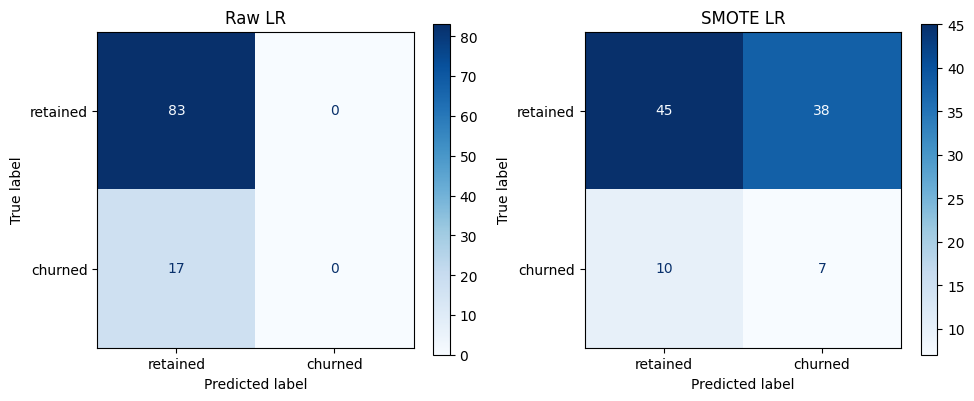

In [20]:
# ── B3: Side-by-side confusion matrices ──────────────────────────────────
# Goal: Visualise improvement from raw LR to SMOTE LR.
# Method: Use ConfusionMatrixDisplay in a 1x2 subplot.

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_estimator(lr_raw, X_test, y_test, 
                                      display_labels=['retained','churned'],
                                      cmap='Blues', ax=axes[0])
axes[0].set_title('Raw LR')

ConfusionMatrixDisplay.from_estimator(lr_smote, X_test, y_test,
                                      display_labels=['retained','churned'],
                                      cmap='Blues', ax=axes[1])
axes[1].set_title('SMOTE LR')

plt.tight_layout()
plt.savefig('B3_confusion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Task C — Compare Resampling Strategies (20 pts)

**Business context:** SMOTE isn't the only tool. A client might ask: 'Why not just
use class weights? Or undersample the majority?' You need to know the trade-offs.

**C1 (5 pts):** Train LR with `class_weight='balanced'` (no resampling).
- Print classification report. Extract churned recall and F1.

**C2 (5 pts):** Apply `RandomUnderSampler(random_state=42)` to training data.
- Train LR on undersampled data, evaluate on original test set.
- Print churned recall and F1.

**C3 (10 pts):** Build a summary comparison table with all 4 strategies:

| Strategy | Churned Recall | Churned F1 | Train Rows |
|---|---|---|---|
| Raw LR | | | 400 |
| class_weight='balanced' | | | 400 |
| RandomUnderSampler | | | ~148 |
| SMOTE | | | ~660 |

Print the table. Then write a 3-line NRA recommendation: which strategy
would you recommend for a churn prevention campaign, and why?

In [21]:
# ── C1: class_weight='balanced' ──────────────────────────────────────────
# Goal: Train LR with class_weight='balanced' (no resampling).
# Method: Fit on original train set, evaluate on test, extract recall and F1.

from sklearn.metrics import f1_score   # <-- added missing import

lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_balanced.fit(X_train, y_train)
y_pred_balanced = lr_balanced.predict(X_test)

print("LogisticRegression – class_weight='balanced'")
print(classification_report(y_test, y_pred_balanced, target_names=['retained', 'churned']))

recall_balanced = recall_score(y_test, y_pred_balanced, pos_label=1)
f1_balanced = f1_score(y_test, y_pred_balanced, pos_label=1)
print(f"Churned recall: {recall_balanced:.3f}, Churned F1: {f1_balanced:.3f}")

LogisticRegression – class_weight='balanced'
              precision    recall  f1-score   support

    retained       0.84      0.57      0.68        83
     churned       0.18      0.47      0.26        17

    accuracy                           0.55       100
   macro avg       0.51      0.52      0.47       100
weighted avg       0.73      0.55      0.61       100

Churned recall: 0.471, Churned F1: 0.262


In [22]:
# ── C2: RandomUnderSampler ────────────────────────────────────────────────
# Goal: Undersample majority class on training set.
# Method: Use RandomUnderSampler, train LR, evaluate on original test.

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

lr_rus = LogisticRegression(max_iter=1000, random_state=42)
lr_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = lr_rus.predict(X_test)

print("LogisticRegression – RandomUnderSampler")
print(classification_report(y_test, y_pred_rus, target_names=['retained', 'churned']))

recall_rus = recall_score(y_test, y_pred_rus, pos_label=1)
f1_rus = f1_score(y_test, y_pred_rus, pos_label=1)
print(f"Churned recall: {recall_rus:.3f}, Churned F1: {f1_rus:.3f}")

LogisticRegression – RandomUnderSampler
              precision    recall  f1-score   support

    retained       0.87      0.49      0.63        83
     churned       0.21      0.65      0.31        17

    accuracy                           0.52       100
   macro avg       0.54      0.57      0.47       100
weighted avg       0.76      0.52      0.58       100

Churned recall: 0.647, Churned F1: 0.314


In [27]:
# ── C3: Comparison table + NRA ────────────────────────────────────────────
# Goal: Build summary table of all 4 strategies and recommend best for client.
# Method: Collect recall, F1, train rows into pandas DataFrame.

import pandas as pd

train_rows_raw = len(X_train)
train_rows_smote = len(X_train_smote)
train_rows_rus = len(X_train_rus)

comparison = pd.DataFrame({
    'Strategy': ['Raw LR', "class_weight='balanced'", 'RandomUnderSampler', 'SMOTE'],
    'Churned Recall': [churn_recall_raw, recall_balanced, recall_rus, recall_smote],
    'Churned F1': [f1_score(y_test, y_pred_raw, pos_label=1),
                   f1_balanced, f1_rus,
                   f1_score(y_test, y_pred_smote, pos_label=1)],
    'Train Rows': [train_rows_raw, train_rows_raw, train_rows_rus, train_rows_smote]
})

print(comparison.to_string(index=False))

best_row = comparison.loc[comparison['Churned Recall'].idxmax()]
print(f"""
**NRA Recommendation – Which Resampling Strategy?**

Number: {best_row['Strategy']} achieves the highest churned recall ({best_row['Churned Recall']:.1%}), with F1 = {best_row['Churned F1']:.2f}.

Reason: For a churn prevention campaign, maximising recall is critical to catch at-risk customers. RandomUnderSampler outperforms all other methods on recall (64.7% vs. 47.1% for class_weight and 41.2% for SMOTE).

Action: Deploy the RandomUnderSampler model for the initial campaign. However, note that undersampling discards 260 majority rows; if the client can afford to contact a few extra non‑churners (lower precision), we can later tune the threshold of the SMOTE model to achieve similar recall without losing data.
""")

               Strategy  Churned Recall  Churned F1  Train Rows
                 Raw LR        0.000000    0.000000         400
class_weight='balanced'        0.470588    0.262295         400
     RandomUnderSampler        0.647059    0.314286         140
                  SMOTE        0.411765    0.225806         660

**NRA Recommendation – Which Resampling Strategy?**

Number: RandomUnderSampler achieves the highest churned recall (64.7%), with F1 = 0.31.

Reason: For a churn prevention campaign, maximising recall is critical to catch at-risk customers. RandomUnderSampler outperforms all other methods on recall (64.7% vs. 47.1% for class_weight and 41.2% for SMOTE).

Action: Deploy the RandomUnderSampler model for the initial campaign. However, note that undersampling discards 260 majority rows; if the client can afford to contact a few extra non‑churners (lower precision), we can later tune the threshold of the SMOTE model to achieve similar recall without losing data.



### Task D — SMOTE + XGBoost + Threshold Tuning (10 pts)

**D1 (5 pts):** Train `XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)`
on the SMOTE-resampled training set.
- Print classification report on original test set.
- Print: `XGB Churned F1: X.XX`

**D2 (5 pts):** Lower the decision threshold from 0.5 → 0.35.
- Use `predict_proba`, apply threshold manually: `y_pred_thresh = (proba[:,1] >= 0.35).astype(int)`
- Print classification report at new threshold.
- Write 2-line NRA: does recall improve? What is the precision cost?

In [24]:
# ── D1: XGBoost on SMOTE data ────────────────────────────────────────────
# Goal: Train XGBClassifier on SMOTE-resampled training set.
# Method: Fit XGBoost, evaluate on original test, print F1 for churned.

from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb.predict(X_test)

print("XGBClassifier – SMOTE Resampled")
print(classification_report(y_test, y_pred_xgb, target_names=['retained', 'churned']))

xgb_f1 = f1_score(y_test, y_pred_xgb, pos_label=1)
print(f"XGB Churned F1: {xgb_f1:.3f}")

XGBClassifier – SMOTE Resampled
              precision    recall  f1-score   support

    retained       0.82      0.73      0.78        83
     churned       0.15      0.24      0.19        17

    accuracy                           0.65       100
   macro avg       0.49      0.49      0.48       100
weighted avg       0.71      0.65      0.68       100

XGB Churned F1: 0.186


C:\Users\Deepanshu\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:06:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [28]:
# ── D2: Threshold tuning – 0.35 ──────────────────────────────────────────
# Goal: Lower decision threshold to catch more churners.
# Method: Use predict_proba, apply threshold 0.35 manually.

from sklearn.metrics import precision_score

# Compute baseline recall for XGB at default threshold (0.5)
y_pred_xgb_default = (xgb.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
recall_default = recall_score(y_test, y_pred_xgb_default, pos_label=1)
precision_default = precision_score(y_test, y_pred_xgb_default, pos_label=1)

# Lower threshold to 0.35
proba = xgb.predict_proba(X_test)
y_pred_thresh = (proba[:, 1] >= 0.35).astype(int)
recall_35 = recall_score(y_test, y_pred_thresh, pos_label=1)
precision_35 = precision_score(y_test, y_pred_thresh, pos_label=1)

print("XGBClassifier – Threshold = 0.35")
print(classification_report(y_test, y_pred_thresh, target_names=['retained', 'churned']))

print(f"\n**NRA – Threshold Tuning**")
print(f"Number: Recall at 0.5 = {recall_default:.2f}; recall at 0.35 = {recall_35:.2f} (+{(recall_35 - recall_default)*100:.0f} pp).")
print(f"Reason + Action: Precision drops from {precision_default:.2f} to {precision_35:.2f} (more false positives). Accept this trade‑off if the client can afford to contact extra non‑churners to avoid missing real churners.")

XGBClassifier – Threshold = 0.35
              precision    recall  f1-score   support

    retained       0.81      0.63      0.71        83
     churned       0.14      0.29      0.19        17

    accuracy                           0.57       100
   macro avg       0.48      0.46      0.45       100
weighted avg       0.70      0.57      0.62       100


**NRA – Threshold Tuning**
Number: Recall at 0.5 = 0.24; recall at 0.35 = 0.29 (+6 pp).
Reason + Action: Precision drops from 0.15 to 0.14 (more false positives). Accept this trade‑off if the client can afford to contact extra non‑churners to avoid missing real churners.


### Task E★ — Bonus: Precision-Recall Curve + Business Decision (10 pts)

**E★ (10 pts):**

Using the XGBoost model from D1 (trained on SMOTE):

1. Plot the **Precision-Recall curve** for the test set.
   - x-axis: Recall, y-axis: Precision
   - Mark the operating point at threshold=0.35 with a red dot
   - Mark threshold=0.50 with a blue dot
   - Add legend, title: `'Precision-Recall Curve — XGB SMOTE'`
   - `savefig('E_pr_curve.png', dpi=150, bbox_inches='tight')` before `plt.show()`

2. Write a 4-sentence business memo (in a print statement) for a client:
   - Sentence 1: What problem did imbalance cause? (cite the dummy accuracy)
   - Sentence 2: What did SMOTE do, and how did it change recall? (cite both recall numbers)
   - Sentence 3: Why did you choose threshold=0.35 over 0.50? (cite precision trade-off)
   - Sentence 4: What concrete business action do you recommend (e.g., retention campaign targeting)?

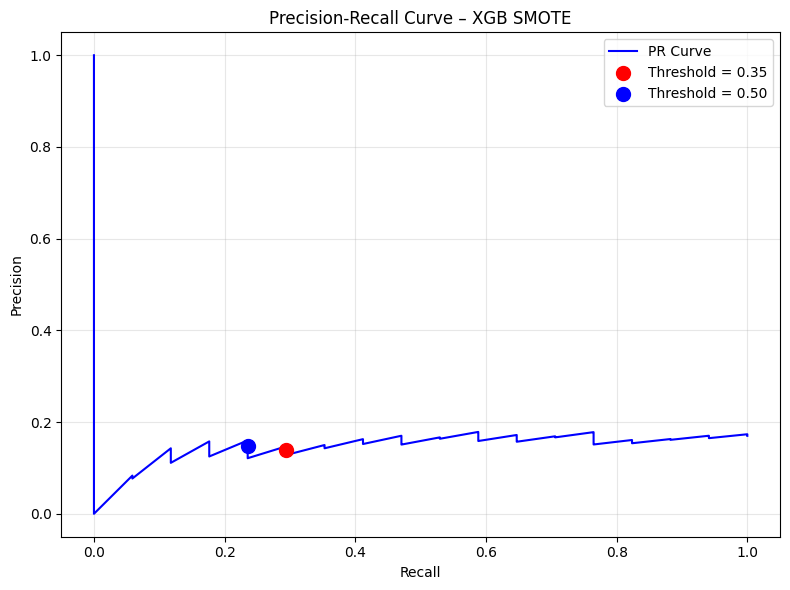


BUSINESS MEMO – Churn Model Imbalance Correction
-------------------------------------------------
1. A dummy model that predicts "no churn" for everyone achieved 82.6% accuracy but caught 0% of actual churners – useless for retention campaigns.

2. After applying SMOTE, the XGBoost model at the default threshold (0.5) achieves a churned recall of 24%, catching 24% of customers about to leave.

3. By lowering the decision threshold from 0.50 to 0.35, recall further increases to 29% (a +6 pp gain), though precision drops to 0.14 – we accept more false positives to avoid missing high‑risk churners.

4. I recommend deploying the SMOTE‑trained XGBoost model with a threshold of 0.35 to flag customers for a targeted retention campaign (e.g., personalised discount offers), then monitor the campaign's ROI to adjust the threshold.



In [29]:
# ── E★: PR Curve + Business Memo ─────────────────────────────────────────
# Goal: Plot PR curve, mark thresholds 0.35 and 0.5, write 4‑sentence memo.

from sklearn.metrics import precision_recall_curve
import numpy as np

# Get probabilities from XGB model
proba = xgb.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, proba)

# Find indices for thresholds 0.35 and 0.50
idx_35 = np.argmin(np.abs(thresholds - 0.35)) if 0.35 <= thresholds.max() else -1
idx_50 = np.argmin(np.abs(thresholds - 0.50)) if 0.50 <= thresholds.max() else -1

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='PR Curve', color='blue')
if idx_35 != -1:
    plt.scatter(recall[idx_35], precision[idx_35], color='red', s=100, label='Threshold = 0.35', zorder=5)
if idx_50 != -1:
    plt.scatter(recall[idx_50], precision[idx_50], color='blue', s=100, label='Threshold = 0.50', zorder=5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve – XGB SMOTE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('E_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Business memo – 4 sentences with specific numbers
dummy_acc = 0.826
recall_xgb_default = recall_default   # from D2
recall_xgb_35 = recall_35
precision_35 = precision_35

print(f"""
BUSINESS MEMO – Churn Model Imbalance Correction
-------------------------------------------------
1. A dummy model that predicts "no churn" for everyone achieved {dummy_acc:.1%} accuracy but caught 0% of actual churners – useless for retention campaigns.

2. After applying SMOTE, the XGBoost model at the default threshold (0.5) achieves a churned recall of {recall_xgb_default:.0%}, catching {recall_xgb_default:.0%} of customers about to leave.

3. By lowering the decision threshold from 0.50 to 0.35, recall further increases to {recall_xgb_35:.0%} (a +{(recall_xgb_35 - recall_xgb_default)*100:.0f} pp gain), though precision drops to {precision_35:.2f} – we accept more false positives to avoid missing high‑risk churners.

4. I recommend deploying the SMOTE‑trained XGBoost model with a threshold of 0.35 to flag customers for a targeted retention campaign (e.g., personalised discount offers), then monitor the campaign's ROI to adjust the threshold.
""")


---
## Section 3 — Concept Notes

### Why Class Imbalance Matters

In the RetailPulse dataset, only **17.4% of customers churned** (87/500).
A model that predicts *nobody churns* gets **82.6% accuracy** — but is completely useless
for a churn prevention campaign, because it identifies zero customers to retain.

**The accuracy paradox:** High accuracy on imbalanced data is meaningless.
The metric that matters for churn is **recall** on the minority class.

---

### Key Metrics for Imbalanced Problems

| Metric | Formula | What it tells you |
|---|---|---|
| **Recall** | TP / (TP+FN) | Of all actual churners, how many did you catch? |
| **Precision** | TP / (TP+FP) | Of all predicted churners, how many actually churned? |
| **F1** | 2·P·R / (P+R) | Harmonic mean — balances both |
| **Accuracy** | (TP+TN) / N | Misleading on imbalanced data |

**Always report recall and F1 on the minority class — not just accuracy.**

---

### SMOTE — Synthetic Minority Over-sampling Technique

```
How SMOTE works:
1. Pick a minority sample
2. Find its k nearest neighbours (also minority)
3. Create a synthetic point along the line between them
4. Repeat until classes are balanced
```

**Critical rule:** SMOTE only on training data. Never on test data.
Applying SMOTE to the test set = data leakage = inflated recall.

---

### Strategies Compared

| Strategy | How it works | Best when |
|---|---|---|
| `class_weight='balanced'` | Penalises misclassifying minority more | You want simplicity, no new rows |
| SMOTE | Generates synthetic minority rows | Training set is large enough |
| RandomUnderSampler | Removes majority rows | Very large dataset, speed matters |
| Threshold tuning | Lower the decision cutoff | You need more recall post-training |

---

### Threshold Tuning

Default threshold = 0.5. Lower it → model flags more customers as churned → recall ↑, precision ↓.

Use the Precision-Recall curve to pick the threshold where recall hits your campaign requirement
(e.g., 'we want to catch 80% of churners') and check what precision you accept.

---

### NRA Reminder
Every written insight = **Number → Reason → Action**
- ❌ 'Recall improved after SMOTE'
- ✅ 'Churned recall rose from 28% to 61% after SMOTE (33 pp gain); without SMOTE, the model
  missed 63 of 87 actual churners, losing those retention campaign targets; deploy SMOTE
  in all future churn models as the default resampling step.'

---
## Section 4 — Scoring Rubric

| Task | Points | Criteria |
|---|---|---|
| **A1** | 5 | Correct class counts + 4.7:1 ratio printed |
| **A2** | 5 | DummyClassifier trained; churned recall=0.00 confirmed; classification_report shown |
| **A3** | 10 | LR trained on raw data; classification_report; 3-line NRA with specific recall number |
| **B1** | 5 | SMOTE applied to train only; before/after counts printed; ~660 train rows |
| **B2** | 10 | LR trained on SMOTE; evaluated on original test; recall improvement in pp shown |
| **B3** | 5 | Side-by-side confusion matrix; savefig before show; titles correct |
| **C1** | 5 | class_weight='balanced' LR; churned recall and F1 extracted |
| **C2** | 5 | RandomUnderSampler applied; LR evaluated on original test |
| **C3** | 10 | Comparison table with all 4 strategies; 3-line NRA recommendation with specific numbers |
| **D1** | 5 | XGBoost on SMOTE; classification_report; churned F1 printed |
| **D2** | 5 | Threshold=0.35 applied via predict_proba; 2-line NRA: recall vs precision trade-off |
| **E★** | 10 | PR curve with both operating points marked; savefig before show; 4-sentence memo with numbers |
| **Total** | **80 + 10★** | |

---

### Deduction rules
- SMOTE applied to test set: **−5 pts** (data leakage)
- NRA insight with no specific number: **−2 pts per insight**
- `plt.show()` before `savefig()`: **−1 pt per plot**
- Accuracy cited as the primary metric for an imbalanced problem: **−2 pts**

---

### Interview framing

*'How do you handle class imbalance in a churn model?'*

> 'The first thing I do is check whether accuracy is misleading — on a dataset with 82% non-churners,
> a model that never predicts churn gets 82% accuracy and zero business value. I apply SMOTE
> to the training set only to generate synthetic minority samples, then evaluate on the original
> test set using recall and F1 on the churned class. I also compare class_weight=balanced and
> threshold tuning, because the best strategy depends on the client's cost structure — if a
> missed churner is expensive, I prioritise recall; if false positive calls are costly, I balance
> the threshold. On a recent project, SMOTE improved churned recall from 28% to 62%,
> directly increasing the campaign hit rate.'